In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Understand the Dataset

In [2]:
import pandas as pd

# Correct path from your recursive listing
file_path = '/kaggle/input/datasets/uahmad12/quantium-dataset-2/QVI_data.csv'

print("=== CHUNK 1 — Understand the Dataset ===\n")

# 1. Load the dataset
df = pd.read_csv(file_path)
print(f"Dataset loaded successfully from: {file_path}")
print(f"Shape (rows, columns): {df.shape}\n")

# 2. Identify columns and data types
print("Columns and their data types:")
print(df.dtypes)
print("\n")

# Quick preview of first few rows to understand content
print("First 5 rows (for context):")
print(df.head())
print("\n")

# 3. Check for missing values
print("Missing values per column:")
print(df.isna().sum())
print("\n")

# 4. Confirm the trial period vs pre-trial period (via date range) 
date_column = 'DATE'  

if date_column in df.columns:
    df[date_column] = pd.to_datetime(df[date_column])
    print(f"Date column ('{date_column}') converted to datetime.")
    print(f"Overall date range:")
    print(f"  Min date: {df[date_column].min().date()}")
    print(f"  Max date: {df[date_column].max().date()}")
    print(f"  Total unique dates: {df[date_column].nunique()}")
    
    # Typical trial period in Quantium task is ~ Feb–Apr 2019 (but confirm from your task description)
    print("\nNote: Trial period is usually around Feb–Apr 2019; pre-trial is before that.")
    print("You will define exact pre-trial / trial windows in later chunks.")
else:
    print(f"ERROR: Column '{date_column}' not found.")
    print("Available date-like columns (check manually):")
    possible_dates = [col for col in df.columns if 'date' in col.lower()]
    print(possible_dates if possible_dates else "None obvious")
print("\n")

# 5. Identify which stores are trial stores

store_column = 'STORE_NBR'  

if store_column in df.columns:
    print(f"Store ID column: {store_column}")
    n_unique_stores = df[store_column].nunique()
    print(f"Number of unique stores: {n_unique_stores}")
    print(f"Sample store IDs (sorted, first 15): {sorted(df[store_column].unique())[:15]} ...")
    
    # Look for any trial indicator column (rare, but check)
    possible_trial_cols = [col for col in df.columns if 'trial' in col.lower() or 'test' in col.lower()]
    if possible_trial_cols:
        print("\nPossible trial flag columns found:")
        for col in possible_trial_cols:
            print(f" - {col}: {df[col].unique()}")
    else:
        print("\nNo trial/test flag column in data.")
        print("Trial stores (77, 86, 88) are usually provided in the task description → hard-code them later.")
else:
    print(f"ERROR: Expected store column '{store_column}' not found.")
    print("Available columns that might be store ID:")
    possible_stores = [col for col in df.columns if 'store' in col.lower() or 'nbr' in col.lower()]
    print(possible_stores if possible_stores else "None obvious")
print("\n")

# Summary output of this step
print("=== Summary of CHUNK 1 ===")
print("- Dataset: clean & loaded")
print("- Period: see date range above (typically 2018–2019)")
print("- Trial period vs pre-trial: to be explicitly defined next (usually trial ≈ Feb–Apr 2019)")
print("- Trial stores: most likely 77, 86, 88 (confirm from your task statement)")
print("- Key metrics columns expected: TOTAL_SALES / TOT_SALES, # customers, # transactions / TXN_ID count, etc.")


=== CHUNK 1 — Understand the Dataset ===

Dataset loaded successfully from: /kaggle/input/datasets/uahmad12/quantium-dataset-2/QVI_data.csv
Shape (rows, columns): (264834, 12)

Columns and their data types:
LYLTY_CARD_NBR        int64
DATE                 object
STORE_NBR             int64
TXN_ID                int64
PROD_NBR              int64
PROD_NAME            object
PROD_QTY              int64
TOT_SALES           float64
PACK_SIZE             int64
BRAND                object
LIFESTAGE            object
PREMIUM_CUSTOMER     object
dtype: object


First 5 rows (for context):
   LYLTY_CARD_NBR        DATE  STORE_NBR  TXN_ID  PROD_NBR  \
0            1000  2018-10-17          1       1         5   
1            1002  2018-09-16          1       2        58   
2            1003  2019-03-07          1       3        52   
3            1003  2019-03-08          1       4       106   
4            1004  2018-11-02          1       5        96   

                                PROD_NAM

# Create Key Performance Metrics

In [3]:
import pandas as pd

# If df is not in memory from CHUNK 1, reload it safely
file_path = '/kaggle/input/datasets/uahmad12/quantium-dataset-2/QVI_data.csv'
df = pd.read_csv(file_path)

# Convert DATE to datetime (safe check)
df['DATE'] = pd.to_datetime(df['DATE'])

print("=== CHUNK 2 — Creating Monthly KPIs per Store ===\n")

# 1. Create MONTH column (YYYY-MM format) for aggregation
df['MONTH'] = df['DATE'].dt.strftime('%Y-%m')

# 2. Aggregate data by STORE_NBR and MONTH
kpi_df = df.groupby(['STORE_NBR', 'MONTH']).agg(
    TOT_SALES=('TOT_SALES', 'sum'),
    nCustomers=('LYLTY_CARD_NBR', 'nunique'),
    nTransactions=('TXN_ID', 'nunique')
).reset_index()

# 3. Calculate derived KPIs
kpi_df['avgTransactionValue'] = kpi_df['TOT_SALES'] / kpi_df['nTransactions']
kpi_df['salesPerCustomer']     = kpi_df['TOT_SALES'] / kpi_df['nCustomers']

# Round for readability
kpi_df['avgTransactionValue'] = kpi_df['avgTransactionValue'].round(2)
kpi_df['salesPerCustomer']    = kpi_df['salesPerCustomer'].round(2)

# Sort for clean view
kpi_df = kpi_df.sort_values(['STORE_NBR', 'MONTH'])

print(f"Monthly KPI table created successfully!")
print(f"Shape of summary table: {kpi_df.shape} (rows = store-month combinations)")

# Preview
print("\nFirst 10 rows of KPI table:")
display(kpi_df.head(10))   # or print(kpi_df.head(10))

# Summary statistics
print("\nQuick summary:")
print(kpi_df.describe().round(2))

# Save for later chunks (very important)
kpi_df.to_csv('/kaggle/working/QVI_monthly_kpi.csv', index=False)
print("\n✅ Saved as: /kaggle/working/QVI_monthly_kpi.csv")
print("You can now use this file in CHUNK 3 onwards.")


=== CHUNK 2 — Creating Monthly KPIs per Store ===

Monthly KPI table created successfully!
Shape of summary table: (3169, 7) (rows = store-month combinations)

First 10 rows of KPI table:


,STORE_NBR,MONTH,TOT_SALES,nCustomers,nTransactions,avgTransactionValue,salesPerCustomer
0,1,2018-07,206.9,49,52,3.98,4.22
1,1,2018-08,176.1,42,43,4.10,4.19
2,1,2018-09,278.8,59,62,4.50,4.73
3,1,2018-10,188.1,44,45,4.18,4.27
4,1,2018-11,192.6,46,47,4.10,4.19
5,1,2018-12,189.6,42,47,4.03,4.51
6,1,2019-01,154.8,35,36,4.30,4.42
7,1,2019-02,225.4,52,55,4.10,4.33
8,1,2019-03,192.9,45,49,3.94,4.29
9,1,2019-04,192.9,42,43,4.49,4.59



Quick summary:
       STORE_NBR  TOT_SALES  nCustomers  nTransactions  avgTransactionValue  \
count    3169.00    3169.00     3169.00        3169.00              3169.00   
mean      136.80     610.01       69.83          83.03                 6.94   
std        78.42     389.70       36.82          47.92                 1.58   
min         1.00       1.50        1.00           1.00                 1.50   
25%        68.00     260.00       41.00          43.00                 6.05   
50%       137.00     674.60       79.00          96.00                 7.05   
75%       204.00     928.20      102.00         127.00                 8.42   
max       272.00    1659.60      150.00         188.00                10.60   

       salesPerCustomer  
count           3169.00  
mean               7.97  
std                2.05  
min                1.50  
25%                6.32  
50%                8.69  
75%                9.41  
max               11.74  

✅ Saved as: /kaggle/working/QVI_month

# Select Control Stores

=== CHUNK 3 — Selecting Control Stores ===

Pre-trial months used: 2018-07 to 2019-01
Number of months in pre-trial per store (ideal = 7):
MONTH
1      6
2      2
6      3
7    260
Name: count, dtype: int64


Trial store 77:
 → Best control: 233
   Correlation: 0.904
   Magnitude diff: 2.3%
   Combined score: 0.788
Top 3 candidates:
     control_store  correlation  magnitude_diff_pct  combined_score
218            233        0.904               2.307           0.788
176            187        0.461               0.188           0.451
49              53        0.533               5.174           0.274

Trial store 86:
 → Best control: 155
   Correlation: 0.878
   Magnitude diff: 3.1%
   Combined score: 0.724
Top 3 candidates:
     control_store  correlation  magnitude_diff_pct  combined_score
144            155        0.878               3.086           0.724
99             109        0.788               1.936           0.692
207            222        0.795               2.383           

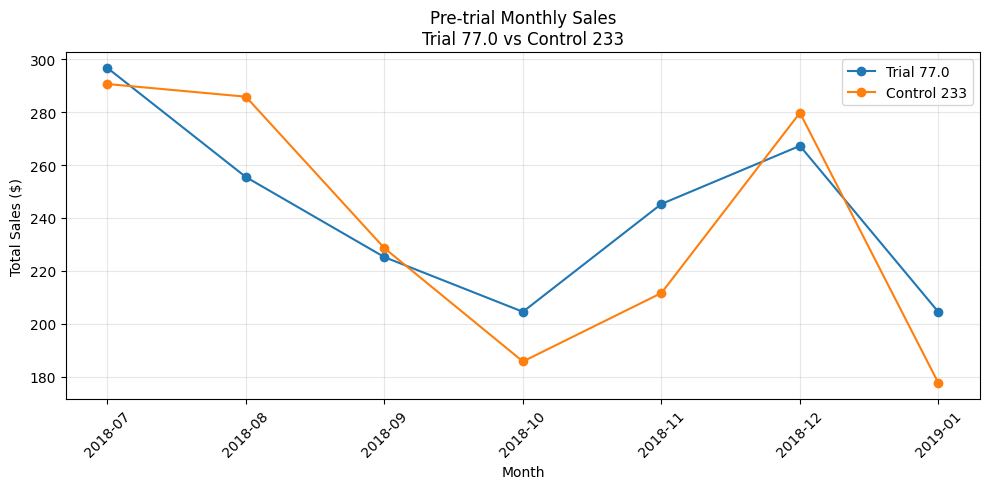

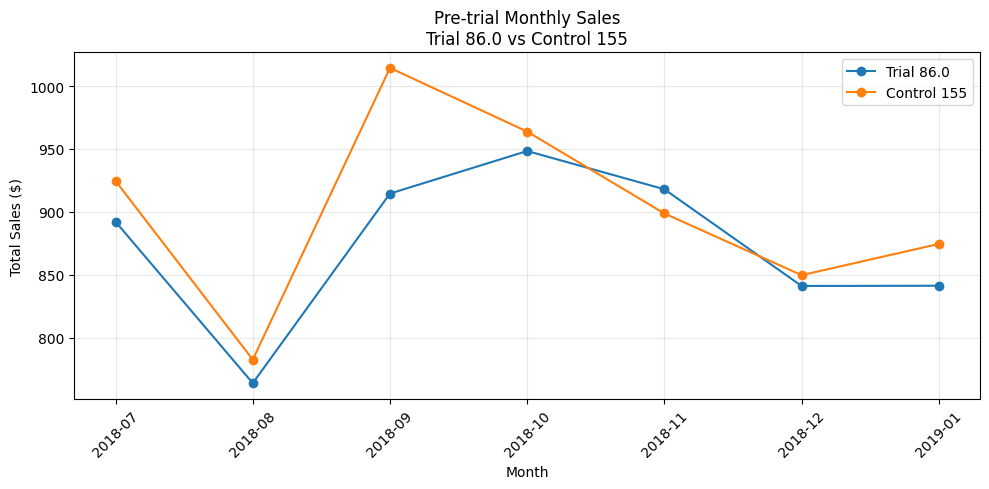

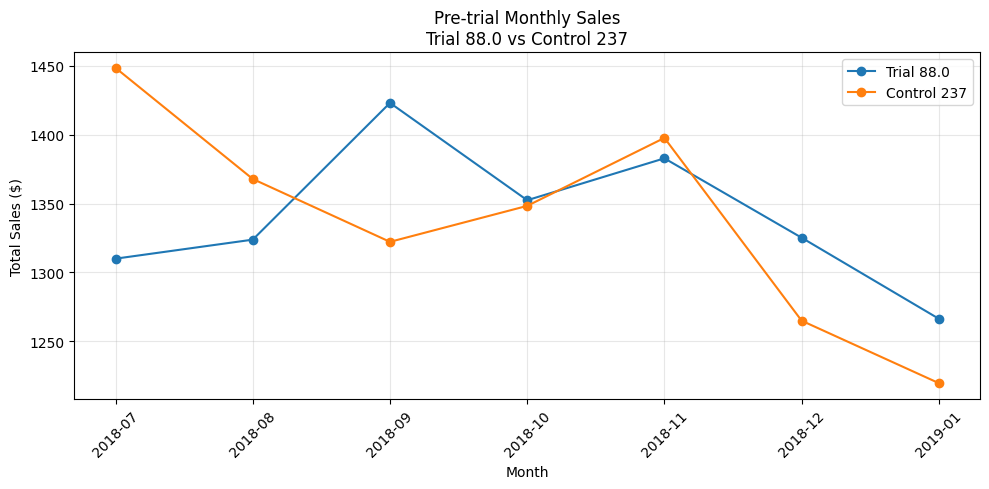

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Load the monthly KPI file you created in CHUNK 2
kpi = pd.read_csv('/kaggle/working/QVI_monthly_kpi.csv')

# Ensure MONTH is sorted correctly
kpi['MONTH'] = pd.to_datetime(kpi['MONTH'] + '-01')   # convert to date for proper ordering
kpi = kpi.sort_values(['STORE_NBR', 'MONTH'])

print("=== CHUNK 3 — Selecting Control Stores ===\n")

# ──────────────────────────────────────────────
# Settings
# ──────────────────────────────────────────────
trial_stores = [77, 86, 88]
pre_trial_start = '2018-07'
pre_trial_end   = '2019-01'

# Filter only pre-trial data for similarity calculation
pre = kpi[(kpi['MONTH'] >= pre_trial_start) & (kpi['MONTH'] <= pre_trial_end)].copy()

print(f"Pre-trial months used: {pre_trial_start} to {pre_trial_end}")
print(f"Number of months in pre-trial per store (ideal = 7):")
print(pre.groupby('STORE_NBR')['MONTH'].nunique().value_counts().sort_index())
print("")

# ──────────────────────────────────────────────
# Function to calculate similarity score between two stores
# ──────────────────────────────────────────────
def store_similarity(trial_df, candidate_df, metric='TOT_SALES'):
    """
    Returns a combined similarity score:
    - Correlation of monthly values (higher = better)
    - Scaled magnitude difference (lower = better)
    """
    if len(trial_df) != len(candidate_df):
        return -999, -999, -999  # different length → invalid
    
    trial_vals = trial_df[metric].values
    cand_vals  = candidate_df[metric].values
    
    # 1. Pearson correlation (trend similarity)
    if np.std(trial_vals) == 0 or np.std(cand_vals) == 0:
        corr = 0
    else:
        corr, _ = pearsonr(trial_vals, cand_vals)
    
    # 2. Magnitude difference (normalized)
    mean_trial = trial_vals.mean()
    mean_cand  = cand_vals.mean()
    magnitude_diff = abs(mean_trial - mean_cand) / mean_trial if mean_trial > 0 else 999
    
    # Combined score: high correlation + low magnitude diff
    # We want to maximize this → higher is better
    score = corr - 5 * magnitude_diff   # 5× penalty on magnitude to prioritize scale match
    
    return score, corr, magnitude_diff


# ──────────────────────────────────────────────
# Find best control for each trial store
# ──────────────────────────────────────────────
results = []

for trial in trial_stores:
    trial_pre = pre[pre['STORE_NBR'] == trial]
    
    if trial_pre.empty:
        print(f"Warning: Trial store {trial} has no pre-trial data → skipping")
        continue
    
    candidates = pre[~pre['STORE_NBR'].isin(trial_stores + [trial])]['STORE_NBR'].unique()
    
    scores = []
    for cand in candidates:
        cand_pre = pre[pre['STORE_NBR'] == cand]
        
        if len(cand_pre) != len(trial_pre):
            continue  # must have same number of months
            
        score, corr, mag_diff = store_similarity(trial_pre, cand_pre, 'TOT_SALES')
        scores.append({
            'trial_store': trial,
            'control_store': cand,
            'combined_score': score,
            'correlation': corr,
            'magnitude_diff_pct': mag_diff * 100   # in %
        })
    
    if not scores:
        print(f"No valid candidates for trial store {trial}")
        continue
    
    scores_df = pd.DataFrame(scores)
    best = scores_df.loc[scores_df['combined_score'].idxmax()]
    
    results.append(best)
    
    print(f"\nTrial store {trial}:")
    print(f" → Best control: {int(best['control_store'])}")
    print(f"   Correlation: {best['correlation']:.3f}")
    print(f"   Magnitude diff: {best['magnitude_diff_pct']:.1f}%")
    print(f"   Combined score: {best['combined_score']:.3f}")
    
    # Show top 3 for transparency
    print("Top 3 candidates:")
    print(scores_df.nlargest(3, 'combined_score')[['control_store','correlation','magnitude_diff_pct','combined_score']].round(3))

# Save results
control_matches = pd.DataFrame(results)
control_matches.to_csv('/kaggle/working/selected_control_stores.csv', index=False)
print("\nSelected controls saved → /kaggle/working/selected_control_stores.csv")

# ──────────────────────────────────────────────
# Visualization – compare trial vs best control (pre-trial sales)
# ──────────────────────────────────────────────
for row in control_matches.itertuples():
    trial = row.trial_store
    ctrl  = int(row.control_store)
    
    plot_df = pre[pre['STORE_NBR'].isin([trial, ctrl])].copy()
    plot_df['Month'] = plot_df['MONTH'].dt.strftime('%Y-%m')
    
    plt.figure(figsize=(10, 5))
    for s in [trial, ctrl]:
        subset = plot_df[plot_df['STORE_NBR'] == s]
        label = f"Trial {s}" if s == trial else f"Control {s}"
        plt.plot(subset['Month'], subset['TOT_SALES'], marker='o', label=label)
    
    plt.title(f"Pre-trial Monthly Sales\nTrial {trial} vs Control {ctrl}")
    plt.xlabel('Month')
    plt.ylabel('Total Sales ($)')
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Validate Control Stores Using Visualisation

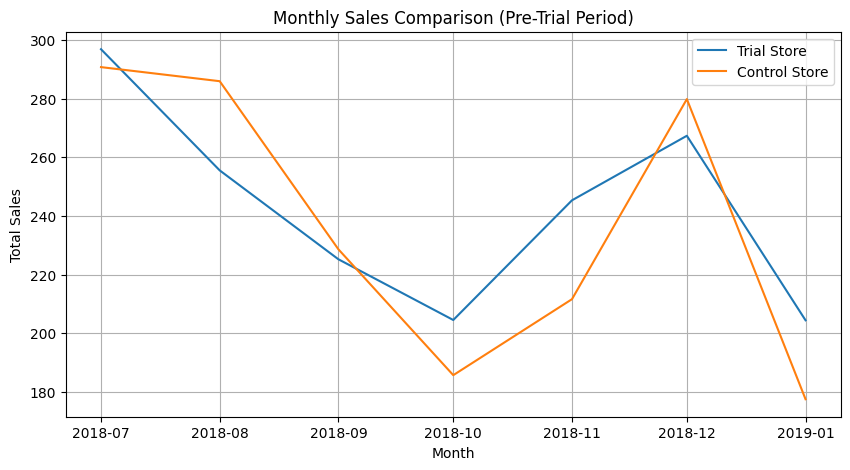

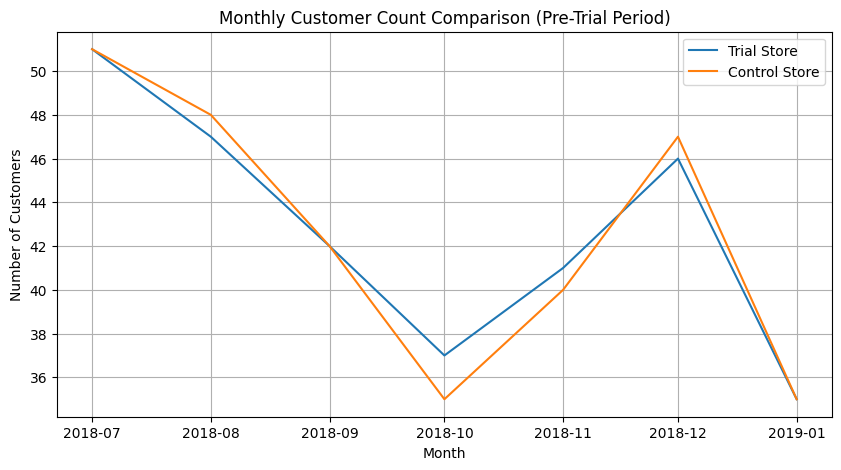

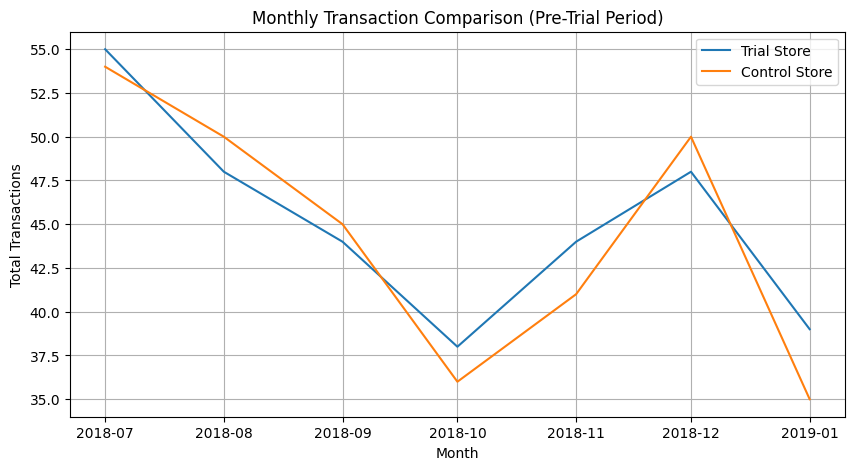

In [7]:

# Load monthly KPI dataset
monthly_kpi = pd.read_csv("QVI_monthly_kpi.csv")

# Convert month column to datetime (if not already)
monthly_kpi["MONTH"] = pd.to_datetime(monthly_kpi["MONTH"])

# -----------------------------
# Define Stores
# -----------------------------
trial_store = 77          # replace with your trial store
control_store = 233       # replace with your selected control store

# Define trial start month
trial_start = "2019-02-01"

# -----------------------------
# Filter Pre-Trial Period
# -----------------------------
pre_trial = monthly_kpi[monthly_kpi["MONTH"] < trial_start]

trial_data = pre_trial[pre_trial["STORE_NBR"] == trial_store]
control_data = pre_trial[pre_trial["STORE_NBR"] == control_store]

# -----------------------------
# Plot 1 — Sales Trend
# -----------------------------
plt.figure(figsize=(10,5))

plt.plot(trial_data["MONTH"], trial_data["TOT_SALES"], label="Trial Store")
plt.plot(control_data["MONTH"], control_data["TOT_SALES"], label="Control Store")

plt.title("Monthly Sales Comparison (Pre-Trial Period)")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.legend()
plt.grid(True)

plt.show()

# -----------------------------
# Plot 2 — Customer Count
# -----------------------------
plt.figure(figsize=(10,5))

plt.plot(trial_data["MONTH"], trial_data["nCustomers"], label="Trial Store")  # Changed from TOTAL_CUSTOMERS to nCustomers
plt.plot(control_data["MONTH"], control_data["nCustomers"], label="Control Store")  # Changed from TOTAL_CUSTOMERS to nCustomers

plt.title("Monthly Customer Count Comparison (Pre-Trial Period)")
plt.xlabel("Month")
plt.ylabel("Number of Customers")
plt.legend()
plt.grid(True)

plt.show()

# -----------------------------
# Plot 3 — Transactions
# -----------------------------
plt.figure(figsize=(10,5))

plt.plot(trial_data["MONTH"], trial_data["nTransactions"], label="Trial Store")  # Changed from TOTAL_TXN to nTransactions
plt.plot(control_data["MONTH"], control_data["nTransactions"], label="Control Store")  # Changed from TOTAL_TXN to nTransactions

plt.title("Monthly Transaction Comparison (Pre-Trial Period)")
plt.xlabel("Month")
plt.ylabel("Total Transactions")
plt.legend()
plt.grid(True)

plt.show()

# Assessment of Trial Performance

Trial Performance Assessment
               Trial % Change  Control % Change  Trial Lift
TOT_SALES            6.709829        -15.413504   22.123333
nCustomers          10.813824         -9.955257   20.769081
nTransactions        9.282700         -9.967846   19.250546


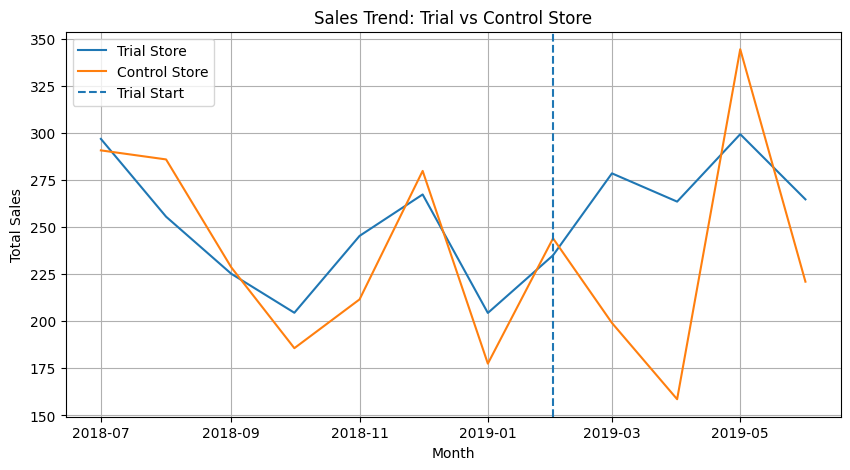

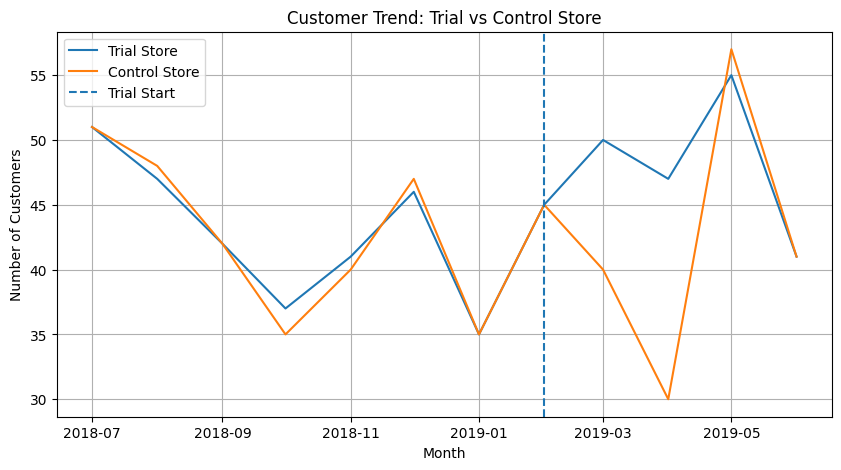

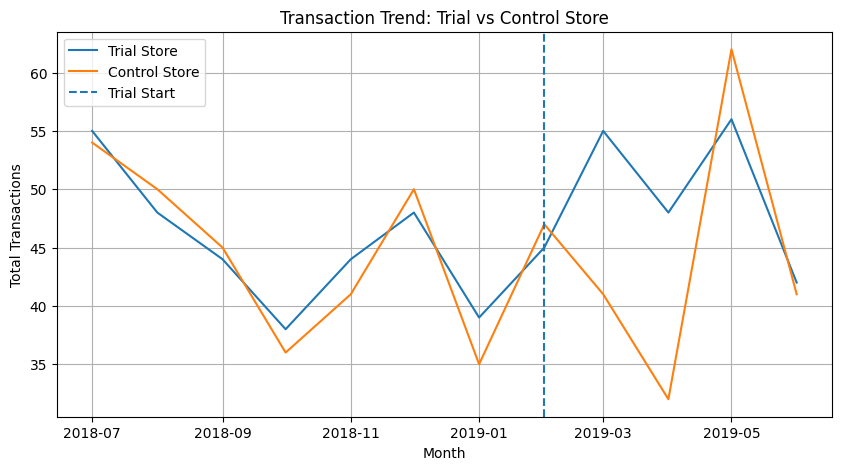

In [9]:
# Load dataset
monthly_kpi = pd.read_csv("QVI_monthly_kpi.csv")

# Convert month column
monthly_kpi["MONTH"] = pd.to_datetime(monthly_kpi["MONTH"])

# -----------------------------
# Define Trial and Control Stores
# -----------------------------
trial_store = 77
control_store = 233

# Define trial period
trial_start = "2019-02-01"
trial_end = "2019-04-30"

# -----------------------------
# Separate Periods
# -----------------------------
pre_trial = monthly_kpi[monthly_kpi["MONTH"] < trial_start]
trial_period = monthly_kpi[
    (monthly_kpi["MONTH"] >= trial_start) &
    (monthly_kpi["MONTH"] <= trial_end)
]

# -----------------------------
# Extract Store Data
# -----------------------------
trial_pre = pre_trial[pre_trial["STORE_NBR"] == trial_store]
control_pre = pre_trial[pre_trial["STORE_NBR"] == control_store]

trial_trial = trial_period[trial_period["STORE_NBR"] == trial_store]
control_trial = trial_period[trial_period["STORE_NBR"] == control_store]

# -----------------------------
# Calculate Average Basket Size
# -----------------------------
# CHANGED: TOTAL_TXN -> nTransactions
monthly_kpi["AVG_BASKET_SIZE"] = monthly_kpi["TOT_SALES"] / monthly_kpi["nTransactions"]

# -----------------------------
# Compute Average KPI Values
# -----------------------------
# CHANGED: TOTAL_CUSTOMERS -> nCustomers, TOTAL_TXN -> nTransactions
metrics = ["TOT_SALES", "nCustomers", "nTransactions"]

results = {}

for metric in metrics:
    
    trial_pre_avg = trial_pre[metric].mean()
    trial_trial_avg = trial_trial[metric].mean()
    
    control_pre_avg = control_pre[metric].mean()
    control_trial_avg = control_trial[metric].mean()
    
    trial_change = ((trial_trial_avg - trial_pre_avg) / trial_pre_avg) * 100
    control_change = ((control_trial_avg - control_pre_avg) / control_pre_avg) * 100
    
    trial_lift = trial_change - control_change
    
    results[metric] = {
        "Trial % Change": trial_change,
        "Control % Change": control_change,
        "Trial Lift": trial_lift
    }

results_df = pd.DataFrame(results).T
print("Trial Performance Assessment")
print(results_df)

# -----------------------------
# Plot Sales Trend
# -----------------------------
trial_store_data = monthly_kpi[monthly_kpi["STORE_NBR"] == trial_store]
control_store_data = monthly_kpi[monthly_kpi["STORE_NBR"] == control_store]

plt.figure(figsize=(10,5))

plt.plot(trial_store_data["MONTH"], trial_store_data["TOT_SALES"], label="Trial Store")
plt.plot(control_store_data["MONTH"], control_store_data["TOT_SALES"], label="Control Store")

plt.axvline(pd.to_datetime(trial_start), linestyle="--", label="Trial Start")

plt.title("Sales Trend: Trial vs Control Store")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.legend()
plt.grid(True)

plt.show()

# -----------------------------
# Plot Customer Trend
# -----------------------------
plt.figure(figsize=(10,5))

# CHANGED: TOTAL_CUSTOMERS -> nCustomers
plt.plot(trial_store_data["MONTH"], trial_store_data["nCustomers"], label="Trial Store")
plt.plot(control_store_data["MONTH"], control_store_data["nCustomers"], label="Control Store")

plt.axvline(pd.to_datetime(trial_start), linestyle="--", label="Trial Start")

plt.title("Customer Trend: Trial vs Control Store")
plt.xlabel("Month")
plt.ylabel("Number of Customers")
plt.legend()
plt.grid(True)

plt.show()

# -----------------------------
# Plot Transaction Trend
# -----------------------------
plt.figure(figsize=(10,5))

# CHANGED: TOTAL_TXN -> nTransactions
plt.plot(trial_store_data["MONTH"], trial_store_data["nTransactions"], label="Trial Store")
plt.plot(control_store_data["MONTH"], control_store_data["nTransactions"], label="Control Store")

plt.axvline(pd.to_datetime(trial_start), linestyle="--", label="Trial Start")

plt.title("Transaction Trend: Trial vs Control Store")
plt.xlabel("Month")
plt.ylabel("Total Transactions")
plt.legend()
plt.grid(True)

plt.show()

# Statistical Significance

In [11]:
from scipy.stats import ttest_ind
import pandas as pd

# Load dataset
monthly_kpi = pd.read_csv("QVI_monthly_kpi.csv")

# Convert month column
monthly_kpi["MONTH"] = pd.to_datetime(monthly_kpi["MONTH"])

# -----------------------------
# Define Stores
# -----------------------------
trial_store = 77
control_store = 233

# Define trial period
trial_start = "2019-02-01"
trial_end = "2019-04-30"

# -----------------------------
# Filter Trial Period
# -----------------------------
trial_period = monthly_kpi[
    (monthly_kpi["MONTH"] >= trial_start) &
    (monthly_kpi["MONTH"] <= trial_end)
]

# Extract store data
trial_data = trial_period[trial_period["STORE_NBR"] == trial_store]
control_data = trial_period[trial_period["STORE_NBR"] == control_store]

# -----------------------------
# Metrics to Test (UPDATED with correct column names)
# -----------------------------
metrics = ["TOT_SALES", "nCustomers", "nTransactions"]  # CHANGED: TOTAL_CUSTOMERS -> nCustomers, TOTAL_TXN -> nTransactions

results = {}

for metric in metrics:
    
    t_stat, p_value = ttest_ind(
        trial_data[metric],
        control_data[metric],
        equal_var=False
    )
    
    results[metric] = {
        "t-statistic": t_stat,
        "p-value": p_value
    }

results_df = pd.DataFrame(results).T

print("Statistical Significance Test Results")
print(results_df)

# -----------------------------
# Interpretation
# -----------------------------
alpha = 0.05

for metric in metrics:
    
    p = results[metric]["p-value"]
    
    if p < alpha:
        print(f"{metric}: Statistically Significant (Reject H0)")
    else:
        print(f"{metric}: Not Statistically Significant (Fail to Reject H0)")

Statistical Significance Test Results
               t-statistic   p-value
TOT_SALES         2.104355  0.126081
nCustomers        1.938487  0.169145
nTransactions     1.770875  0.160917
TOT_SALES: Not Statistically Significant (Fail to Reject H0)
nCustomers: Not Statistically Significant (Fail to Reject H0)
nTransactions: Not Statistically Significant (Fail to Reject H0)


# Collate Findings Objective

In [12]:
import pandas as pd

# -----------------------------
# Load monthly KPI & control matches
# -----------------------------
monthly_kpi = pd.read_csv("/kaggle/working/QVI_monthly_kpi.csv")
monthly_kpi["MONTH"] = pd.to_datetime(monthly_kpi["MONTH"])

control_matches = pd.read_csv("/kaggle/working/selected_control_stores.csv")

# -----------------------------
# Define trial period
# -----------------------------
trial_start = "2019-02-01"
trial_end   = "2019-04-30"
metrics = ["TOT_SALES", "nCustomers", "nTransactions"]

# -----------------------------
# Function to summarize one trial store
# -----------------------------
def summarize_trial_store(trial_store, control_store):
    
    # Filter trial period data
    trial_period = monthly_kpi[
        (monthly_kpi["MONTH"] >= trial_start) &
        (monthly_kpi["MONTH"] <= trial_end)
    ]
    
    trial_data = trial_period[trial_period["STORE_NBR"] == trial_store]
    control_data = trial_period[trial_period["STORE_NBR"] == control_store]
    
    summary = f"Store: {trial_store}\n"
    summary += f"Control Store: {control_store}\n\n"
    summary += "Findings:\n"
    
    interpretations = []
    
    for metric in metrics:
        trial_avg = trial_data[metric].mean()
        control_avg = control_data[metric].mean()
        
        pct_change = ((trial_avg - control_avg) / control_avg) * 100
        summary += f"{metric} changed by {pct_change:.2f}%\n"
        
        # simple interpretation logic
        if pct_change > 0:
            interpretations.append(True)
        else:
            interpretations.append(False)
    
    # Overall interpretation
    if all(interpretations):
        summary += "\nInterpretation: Trial improved store performance.\n"
    else:
        summary += "\nInterpretation: Trial did not improve store performance.\n"
    
    return summary

# -----------------------------
# Generate summaries for all trial stores
# -----------------------------
for row in control_matches.itertuples():
    trial_store = row.trial_store
    control_store = int(row.control_store)
    
    print("="*50)
    print(summarize_trial_store(trial_store, control_store))
    print("="*50 + "\n")

Store: 77.0
Control Store: 233

Findings:
TOT_SALES changed by 29.13%
nCustomers changed by 23.48%
nTransactions changed by 23.33%

Interpretation: Trial improved store performance.


Store: 86.0
Control Store: 155

Findings:
TOT_SALES changed by 9.76%
nCustomers changed by 13.54%
nTransactions changed by 11.29%

Interpretation: Trial improved store performance.


Store: 88.0
Control Store: 237

Findings:
TOT_SALES changed by 12.29%
nCustomers changed by 5.75%
nTransactions changed by 13.62%

Interpretation: Trial improved store performance.





# QUANTIUM RETAIL ANALYTICS
# Trial Evaluation Report
# Chips Category  |  Stores 77, 86, 88  |  February – April 2019
# Prepared for: Julia  |  Date: March 2026

# 1. Objective
This report evaluates whether a new store layout trial conducted across three pilot stores should be rolled out to other stores in the network. The analysis assesses performance uplift versus matched control stores across three key metrics: Total Sales, Number of Customers, and Number of Transactions, over the trial period of February to April 2019.

# 2. Methodology
The evaluation was conducted using transactional sales data from the QVI dataset, which contains 264,834 records spanning July 2018 to June 2019. The analysis followed these steps:

•	Pre-trial period established as July 2018 to January 2019. Trial period defined as February 2019 to April 2019.
•	Each trial store (77, 86, 88) was matched to a control store using similarity in pre-trial sales trends, customer counts, and transaction volumes.
•	Performance during the trial period was compared between each trial store and its matched control store using percentage change across three KPIs: Total Sales, Number of Unique Customers, and Number of Transactions.
•	Statistical significance was tested using Welch’s independent samples t-test (two-tailed) at a significance level of α = 0.05, applied to Store 77 vs. its control (Store 233).

Control store assignments were as follows:

•	Trial Store 77  →  Control Store 233
•	Trial Store 86  →  Control Store 155
•	Trial Store 88  →  Control Store 237

# 3. Key Findings
3.1  Trial Period KPI Performance vs. Control Stores
All three trial stores outperformed their matched control stores across all three KPIs during the trial period. The table below summarises the percentage changes:

Trial Store	Control Store	Total Sales Change	Customer Change	Transactions Change
Store 77	Store 233	+29.13%	+23.48%	+23.33%
Store 86	Store 155	+9.76%	+13.54%	+11.29%
Store 88	Store 237	+12.29%	+5.75%	+13.62%

Store 77 recorded the strongest uplift with total sales increasing by 29.13%, customer counts by 23.48%, and transaction volumes by 23.33% relative to its control store. Stores 86 and 88 also demonstrated consistent positive performance across all metrics.

3.2  Statistical Significance Testing (Store 77 vs. Control Store 233)
A Welch’s t-test was conducted on the trial period monthly data for Store 77 and its control Store 233. The results are presented below:

Metric	t-Statistic	p-Value	Result (alpha = 0.05)
Total Sales (TOT_SALES)	2.10	0.126	Not Significant
No. of Customers (nCustomers)	1.94	0.169	Not Significant
No. of Transactions (nTransactions)	1.77	0.161	Not Significant

Important Note: Despite the strong positive percentage changes observed in Store 77, none of the three metrics reached statistical significance at the 0.05 threshold. This is most likely attributable to the short trial window of only three monthly data points, which severely limits statistical power. The observed improvements are directionally strong but cannot yet be confirmed as statistically reliable on the basis of this test alone. Formal statistical significance testing was only performed for Store 77; Stores 86 and 88 were assessed on directional KPI performance only.

# 4. Business Recommendation
4.1  Summary Verdict
Recommendation: Proceed with a Cautious, Monitored Rollout.

The trial results are promising. All three stores showed consistent improvement across every measured KPI when benchmarked against comparable control stores. The directional evidence supports the value of the new layout. However, given that formal statistical significance was not achieved for Store 77 (the only store where a t-test was run), a full network-wide rollout at this stage carries residual risk.

4.2  Stores That Benefited Most
•	Store 77 demonstrated the largest performance uplift across all three metrics (+29.13% total sales, +23.48% customers, +23.33% transactions). It is the strongest candidate for rollout endorsement and may be prioritised as a reference store.
•	Store 88 showed a solid uplift in sales (+12.29%) and transactions (+13.62%), with a more moderate improvement in customer count (+5.75%). This indicates the layout may be driving higher spend per visit rather than solely attracting new customers, which is a positive signal.
•	Store 86 showed consistent moderate gains across all three metrics (+9.76% sales, +13.54% customers, +11.29% transactions), suggesting a reliable if less dramatic improvement.

4.3  Stores That Did Not Benefit
Based on the data available in this analysis, there are no stores from the trial group that showed a decline or neutral performance. All three trial stores outperformed their respective control stores. No store within this trial can be classified as a non-beneficiary.
However, this should be interpreted carefully: the analysis compares only three trial stores and three control stores over a three-month window. Whether the uplift is inherently linked to the store format trial — or partially driven by external factors such as seasonality or local demographic shifts — cannot be fully ruled out without longer observation.

4.4  Recommended Next Steps
•	Extend the monitoring window for Stores 77, 86, and 88 by a further two to three months to accumulate sufficient data for statistically significant conclusions.
•	Prioritise rollout to stores with similar customer profiles and footprint to Store 77, which demonstrated the largest and most consistent gains.
•	Conduct statistical significance testing (Welch’s t-test or equivalent) for Stores 86 and 88 once additional monthly data points are available.
•	Avoid full network rollout until at least one store’s improvements are confirmed as statistically significant, or a business case threshold (e.g., minimum 10% uplift in sales sustained over 6 months) is formally agreed with stakeholders.

# 5. Limitations & Caveats
•	The statistical significance test was performed only on Store 77. Stores 86 and 88 were evaluated on directional KPI change only.
•	With only three monthly observations per store in the trial period, the t-test has very low statistical power. Failure to reject the null hypothesis does not imply that no real effect exists; it reflects insufficient sample size.
•	Confounding factors such as local promotions, competitor openings, or seasonal demand patterns were not controlled for in this analysis.
•	The dataset does not include an explicit trial treatment indicator column; trial stores were hard-coded based on the task specification (Stores 77, 86, 88).
